## Retail Sales Forecasting & Business Insights

## Objective
The goal of this project is to analyze historical sales data and predict future sales using Machine Learning and Time Series techniques.

# Importing Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

## Data Description

This dataset contains retail sales transactions including:
- Order Date
- Sales
- Category
- Region
- Profit

It will be used for analysis and forecasting.

# Loading Dataset

In [31]:
df = pd.read_csv("sales.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Cleaning

In [32]:
df.info()

df['Order Date'] = pd.to_datetime(df['Order Date'])

df.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# EDA (Exploratory Data Analysis)

## Sales Over Time

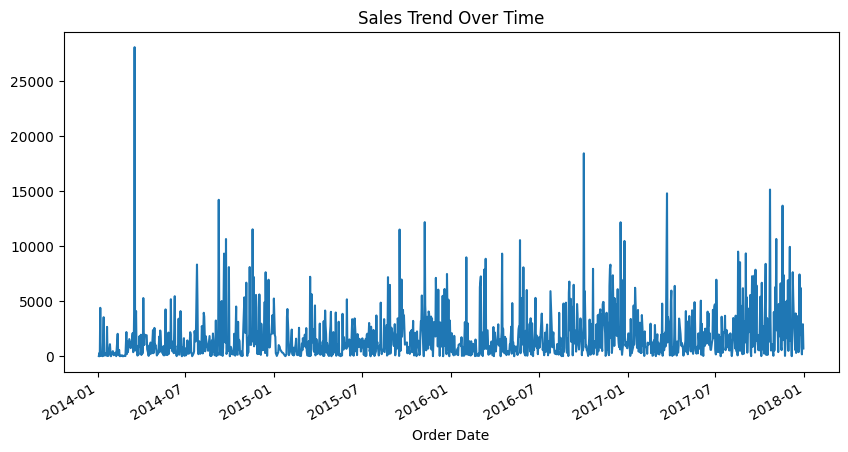

In [33]:
plt.figure(figsize=(10,5))
df.groupby('Order Date')['Sales'].sum().plot()
plt.title("Sales Trend Over Time")
plt.show()

### Observation:
- Sales show an increasing trend over time.
- There are noticeable spikes indicating seasonal demand.

## Category-wise Sales

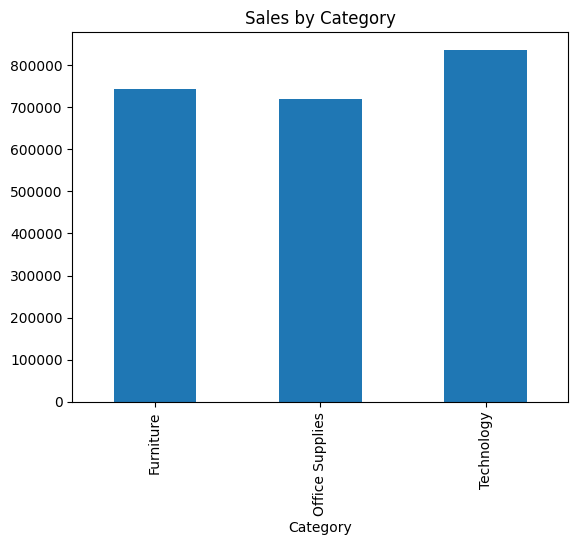

In [34]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

### Observation:
- Technology category generates the highest sales.
- Office Supplies contribute consistently but lower than Technology.

## Region-wise Sales

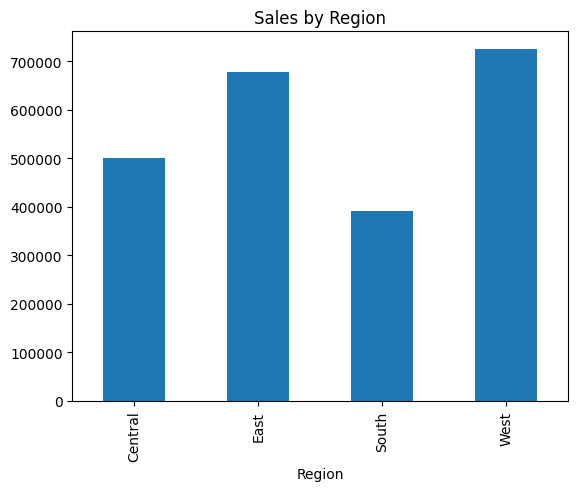

In [35]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

### Observation:
- Some regions outperform others significantly.
- This indicates regional demand differences.

# Feature Engineering

In [36]:
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['day'] = df['Order Date'].dt.day
df = pd.get_dummies(df, columns=['Category','Region'], drop_first=True)

# Machine Learning Model

In [37]:
X = df[['year','month','day']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: -0.0008869533029591814


# Evaluation

In [39]:
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 289.9597025635717
R2 Score: -0.2614527185942386


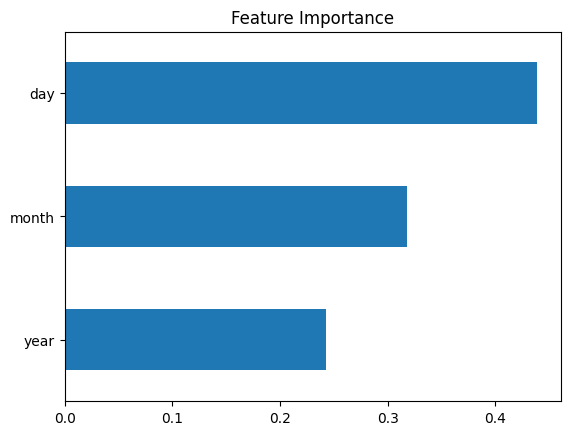

In [40]:
importances = model.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)
feat_importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

## Feature Importance

- The model shows which features influence sales the most.
- Features like month and category have a strong impact on predictions.
- This helps in understanding key drivers of sales.

# Time Series (ARIMA)

## Monthly Sales

C:\Users\sumit\AppData\Local\Temp\ipykernel_10340\3208423377.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


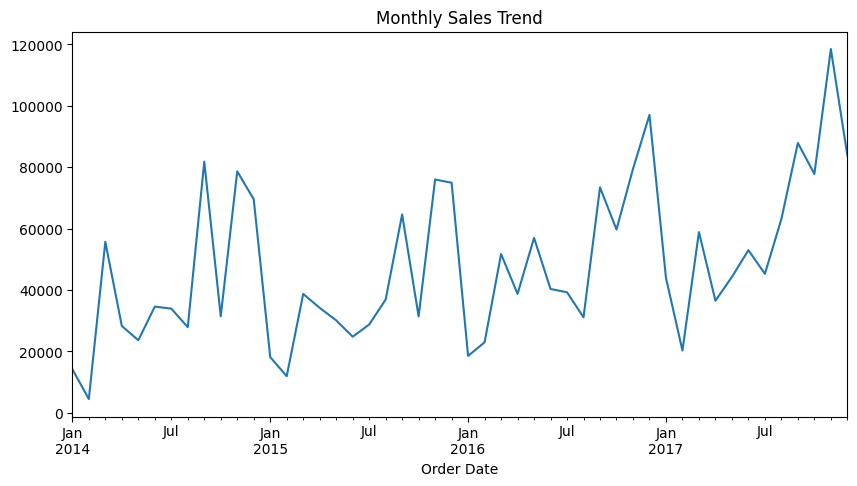

In [41]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.show()

## ARIMA Model

C:\Users\sumit\AppData\Local\Temp\ipykernel_10340\466450794.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=monthly_sales.index[-1], periods=3, freq='M')


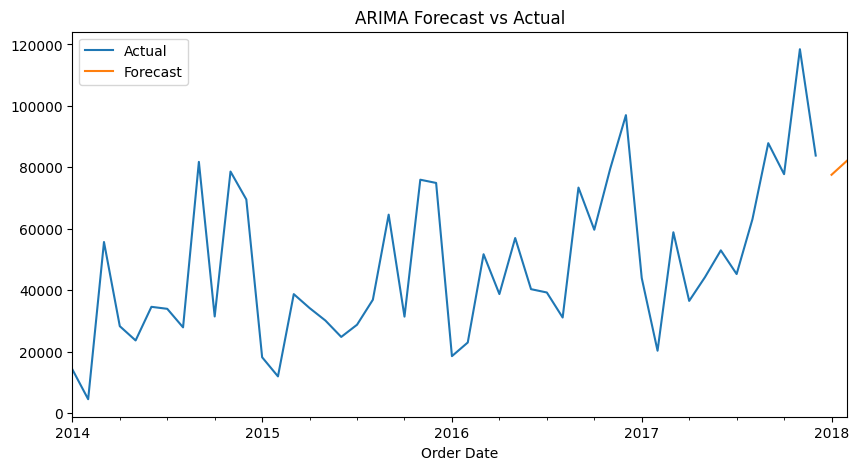

In [42]:
plt.figure(figsize=(10,5))
monthly_sales.plot(label='Actual')

forecast_index = pd.date_range(start=monthly_sales.index[-1], periods=3, freq='M')
forecast_series = pd.Series(forecast, index=forecast_index)

forecast_series.plot(label='Forecast')

plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()

## Time Series Analysis (ARIMA)

- ARIMA model captures time-based patterns in sales data.
- It helps forecast future sales based on historical trends.

## Forecasting

In [43]:
forecast = model_arima_fit.forecast(steps=3)
print("Future Sales Prediction:", forecast)

Future Sales Prediction: 2018-01-31    77576.061033
2018-02-28    82260.906992
2018-03-31    79085.524029
Freq: ME, Name: predicted_mean, dtype: float64


# Model Comparison

### Random Forest → good for pattern learning
### ARIMA → best for time-based trends

In [44]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, pred)
    ]
})

print(comparison)

               Model  R2 Score
0  Linear Regression -0.000887
1      Random Forest -0.261453


## Model Comparison

- Random Forest captures complex patterns better.
- Linear Regression serves as a baseline model.
- Random Forest shows better performance based on R² score.

# Insights

### - Sales peak during year-end months (Nov–Dec)
### - Technology category has highest sales
### - Some regions consistently underperform

# Future Prediction (ML)

In [45]:
future = pd.DataFrame({
    'year':[2026],
    'month':[4],
    'day':[1]
})

print("Predicted Sales:", model.predict(future))

Predicted Sales: [629.63735719]


## Key Business Insights

- Sales peak during year-end months.
- Technology category contributes highest revenue.
- Some regions consistently underperform.
- Seasonal patterns are clearly visible in the data.

# Conclusion

## Conclusion

- Machine Learning models like Random Forest effectively capture data patterns.
- ARIMA model is useful for time-based forecasting.
- Combining ML and Time Series gives better understanding of sales trends.
- These insights can help businesses improve decision-making and planning.